# Módulo A — Detección de Emociones
## Notebook 01: Descarga y Análisis Exploratorio del Dataset GoEmotions

**Proyecto:** PROYECTO MONIKA — Asistente de voz con avatar holográfico (inferencia 100% local)  
**Propósito:** Descargar GoEmotions, analizar la distribución de clases, y definir empíricamente el esquema de etiquetas para el fine-tuning de DistilBERT.  
**Reproducibilidad:** Todas las semillas aleatorias están fijadas. Ejecutar celdas en orden.

---
### Referencias
- Demszky et al. (2020). *GoEmotions: A Dataset of Fine-Grained Emotions*. ACL 2020.  
- Dataset: https://huggingface.co/datasets/google-research-datasets/go_emotions  
- Paper original: https://arxiv.org/abs/2005.00547

## 0. Dependencias

Instalar solo si no están presentes. El notebook detecta el entorno automáticamente.

In [1]:
import importlib, subprocess, sys

REQUIRED = {
    'datasets':     'datasets',
    'pandas':       'pandas',
    'numpy':        'numpy',
    'matplotlib':   'matplotlib',
    'seaborn':      'seaborn',
    'scipy':        'scipy',
    'sklearn':      'scikit-learn',
    'tqdm':         'tqdm',
}

for module, package in REQUIRED.items():
    if importlib.util.find_spec(module) is None:
        print(f'Instalando {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('✓ Todas las dependencias disponibles.')

✓ Todas las dependencias disponibles.


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plot_style import fig_title  # banner-title toggle (MONIKA_FIG_TITLES)
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
from datasets import load_dataset
from tqdm.auto import tqdm

# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Rutas de salida ──────────────────────────────────────────────────────────
OUT_DIR = Path('data')
FIG_DIR = Path('figures')
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ── Estilo de gráficas (paper-ready) ─────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})
sns.set_palette('husl')

print(f'✓ Configuración lista. Semilla: {SEED}')
print(f'  Salida de datos:   {OUT_DIR.resolve()}')
print(f'  Salida de figuras: {FIG_DIR.resolve()}')

✓ Configuración lista. Semilla: 42
  Salida de datos:   /home/aragon/Documentos/PROYECTO MONIKA/Modulo A/data
  Salida de figuras: /home/aragon/Documentos/PROYECTO MONIKA/Modulo A/figures


## 1. Descarga del Dataset

GoEmotions se descarga directamente desde HuggingFace Datasets.  
Contiene ~58,000 comentarios de Reddit anotados con 28 emociones (multi-label) + `neutral`.

In [3]:
print('Descargando GoEmotions desde HuggingFace...')
print('(primera descarga ~50MB, se cachea localmente después)\n')

# 'simplified' = una sola etiqueta por ejemplo (no multi-label)
# 'raw'        = multi-label original
# Descargamos ambas versiones para tener flexibilidad
ds_simplified = load_dataset(
    'google-research-datasets/go_emotions',
    'simplified',
    trust_remote_code=True
)
ds_raw = load_dataset(
    'google-research-datasets/go_emotions',
    'raw',
    trust_remote_code=True
)

print('\n✓ Dataset descargado.')
print(f'  Versión simplified: {ds_simplified}')
print(f'  Versión raw:        {ds_raw}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google-research-datasets/go_emotions' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Descargando GoEmotions desde HuggingFace...
(primera descarga ~50MB, se cachea localmente después)



`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google-research-datasets/go_emotions' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



✓ Dataset descargado.
  Versión simplified: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
  Versión raw:        DatasetDict({
    train: Dataset({
        features: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
        num_rows: 211225
    })
})


In [4]:
# ── Extraer lista oficial de etiquetas ───────────────────────────────────────
LABEL_NAMES: list[str] = ds_simplified['train'].features['labels'].feature.names
N_CLASSES = len(LABEL_NAMES)
LABEL2ID = {name: i for i, name in enumerate(LABEL_NAMES)}
ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}

print(f'Clases ({N_CLASSES} total):')
for i, name in enumerate(LABEL_NAMES):
    print(f'  [{i:2d}] {name}')

Clases (28 total):
  [ 0] admiration
  [ 1] amusement
  [ 2] anger
  [ 3] annoyance
  [ 4] approval
  [ 5] caring
  [ 6] confusion
  [ 7] curiosity
  [ 8] desire
  [ 9] disappointment
  [10] disapproval
  [11] disgust
  [12] embarrassment
  [13] excitement
  [14] fear
  [15] gratitude
  [16] grief
  [17] joy
  [18] love
  [19] nervousness
  [20] optimism
  [21] pride
  [22] realization
  [23] relief
  [24] remorse
  [25] sadness
  [26] surprise
  [27] neutral


In [5]:
# ── Convertir a DataFrames ────────────────────────────────────────────────────
def split_to_df(dataset_split, label_names) -> pd.DataFrame:
    """Convierte un split de HuggingFace Dataset a DataFrame.
    
    Para la versión simplified, cada ejemplo puede tener 0 o más labels.
    Expandimos a una fila por label para análisis de distribución.
    """
    rows = []
    for example in dataset_split:
        for label_id in example['labels']:
            rows.append({
                'text':       example['text'],
                'label_id':   label_id,
                'label_name': label_names[label_id],
            })
    return pd.DataFrame(rows)

print('Convirtiendo splits a DataFrames...')
df_train = split_to_df(ds_simplified['train'],      LABEL_NAMES)
df_val   = split_to_df(ds_simplified['validation'], LABEL_NAMES)
df_test  = split_to_df(ds_simplified['test'],       LABEL_NAMES)
df_all   = pd.concat([df_train, df_val, df_test], keys=['train','val','test']
                    ).reset_index(level=0).rename(columns={'level_0': 'split'})

print(f'\n  Train: {len(df_train):,} filas')
print(f'  Val:   {len(df_val):,} filas')
print(f'  Test:  {len(df_test):,} filas')
print(f'  Total: {len(df_all):,} filas')

# Guardar versión raw para reproducibilidad
df_all.to_parquet(OUT_DIR / 'goemotions_all_splits.parquet', index=False)
print(f'\n✓ Guardado en {OUT_DIR / "goemotions_all_splits.parquet"}')

Convirtiendo splits a DataFrames...

  Train: 51,103 filas
  Val:   6,380 filas
  Test:  6,329 filas
  Total: 63,812 filas

✓ Guardado en data/goemotions_all_splits.parquet


## 2. Análisis de Distribución de Clases

Antes de definir cualquier esquema de etiquetas, entendemos la distribución real del dataset.  
De esta sección se generarán figuras de referencia para el Paper

In [6]:
# ── Conteo por clase (sobre el training set) ──────────────────────────────────
class_counts = (
    df_train['label_name']
    .value_counts()
    .rename_axis('emotion')
    .reset_index(name='count')
)
class_counts['pct'] = class_counts['count'] / class_counts['count'].sum() * 100
class_counts['rank'] = range(1, len(class_counts) + 1)

# Ratio de desbalance
max_count  = class_counts['count'].max()
min_count  = class_counts['count'].min()
imb_ratio  = max_count / min_count
top_class  = class_counts.iloc[0]['emotion']
bot_class  = class_counts.iloc[-1]['emotion']

print('── Estadísticas de distribución (training set) ──')
print(f'  Clase más frecuente: {top_class:<20} ({max_count:,} ejemplos)')
print(f'  Clase más rara:      {bot_class:<20} ({min_count:,} ejemplos)')
print(f'  Ratio de desbalance: {imb_ratio:.1f}:1')
print(f'  Media por clase:     {class_counts["count"].mean():.0f}')
print(f'  Mediana por clase:   {class_counts["count"].median():.0f}')
print()
print(class_counts.to_string(index=False))

── Estadísticas de distribución (training set) ──
  Clase más frecuente: neutral              (14,219 ejemplos)
  Clase más rara:      grief                (77 ejemplos)
  Ratio de desbalance: 184.7:1
  Media por clase:     1825
  Mediana por clase:   1298

       emotion  count       pct  rank
       neutral  14219 27.824198     1
    admiration   4130  8.081717     2
      approval   2939  5.751130     3
     gratitude   2662  5.209088     4
     annoyance   2470  4.833376     5
     amusement   2328  4.555506     6
     curiosity   2191  4.287420     7
          love   2086  4.081952     8
   disapproval   2022  3.956715     9
      optimism   1581  3.093752    10
         anger   1567  3.066356    11
           joy   1452  2.841320    12
     confusion   1368  2.676947    13
       sadness   1326  2.594760    14
disappointment   1269  2.483220    15
   realization   1110  2.172084    16
        caring   1087  2.127077    17
      surprise   1060  2.074242    18
    excitement    85

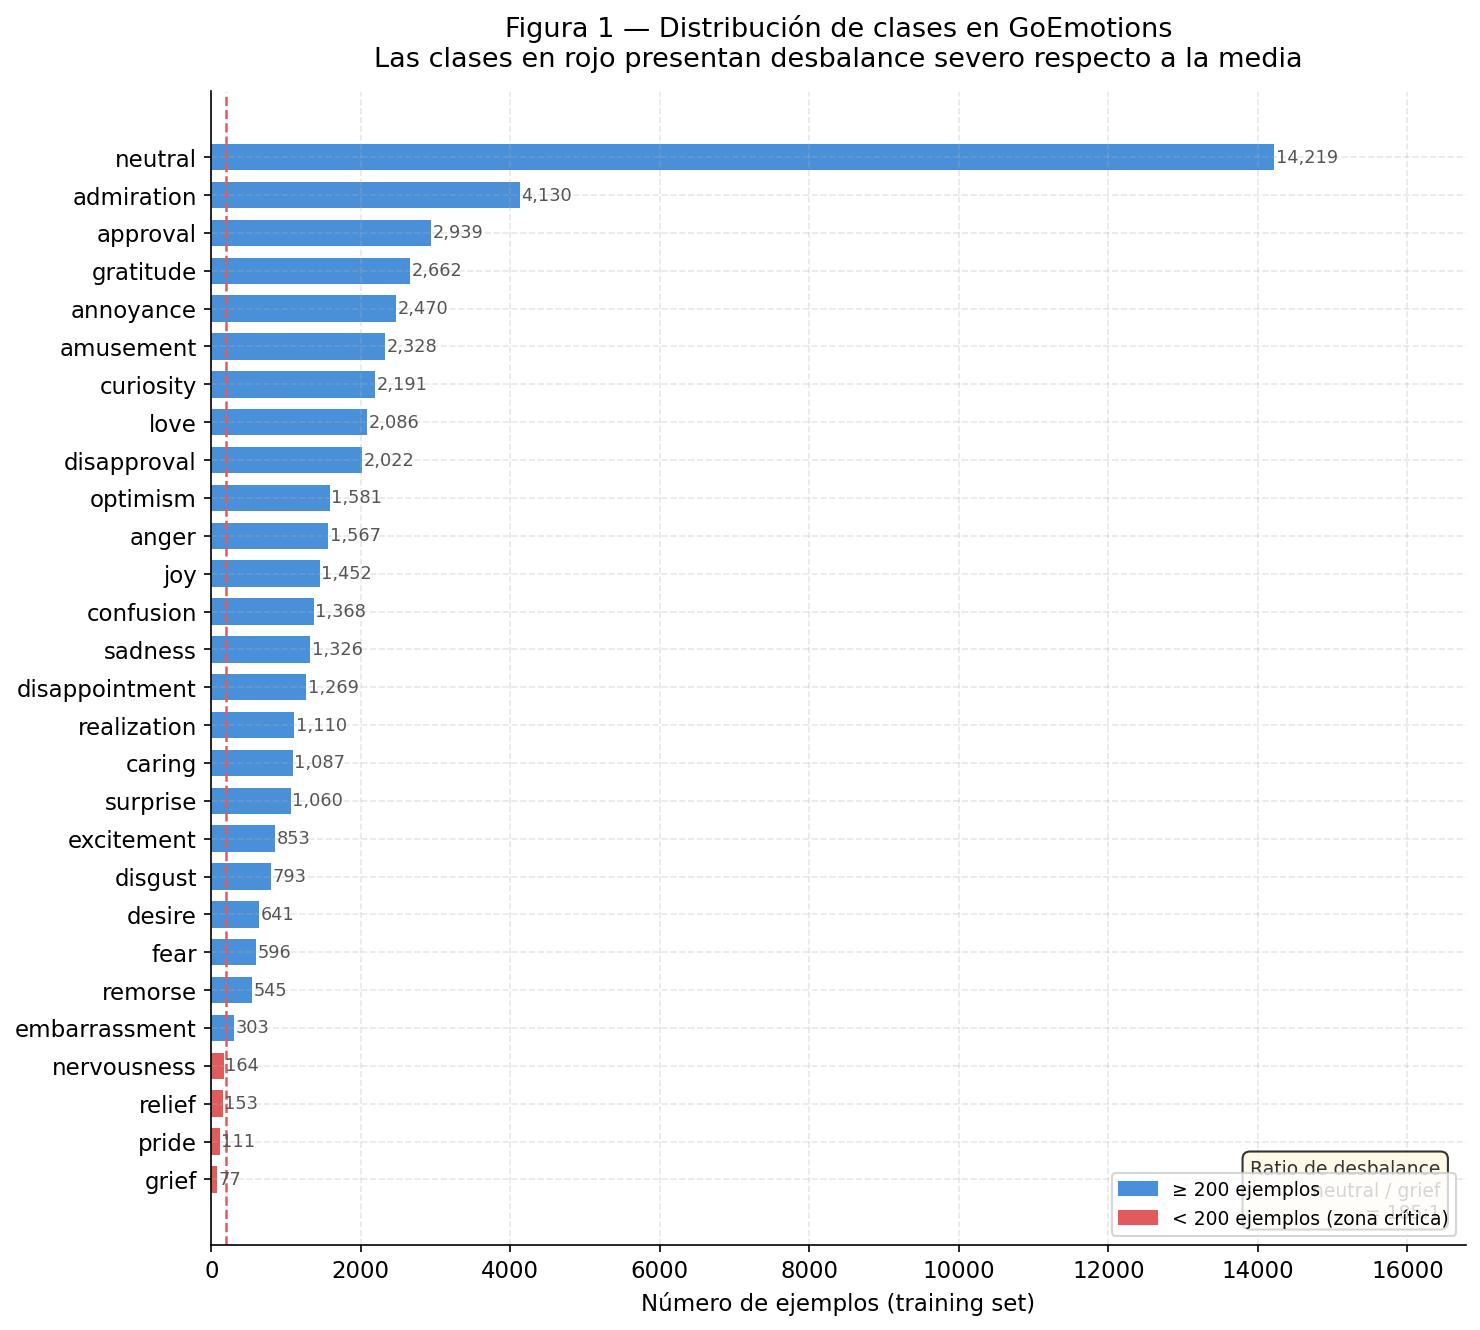

✓ Figura guardada en figures


In [7]:
# ── Figura 1: Distribución de clases (barras horizontales) ────────────────────
# Umbral para marcar zona crítica (clases con menos de 200 ejemplos)
CRITICAL_THRESHOLD = 200

fig, ax = plt.subplots(figsize=(10, 9))

colors = [
    '#e05c5c' if c < CRITICAL_THRESHOLD else '#4a90d9'
    for c in class_counts['count']
]

bars = ax.barh(
    class_counts['emotion'],
    class_counts['count'],
    color=colors,
    edgecolor='none',
    height=0.7,
)

# Línea de umbral crítico
ax.axvline(CRITICAL_THRESHOLD, color='#e05c5c', linestyle='--',
           linewidth=1.2, label=f'Umbral crítico ({CRITICAL_THRESHOLD} ejemplos)')

# Anotaciones de conteo
for bar, count in zip(bars, class_counts['count']):
    ax.text(
        bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
        f'{count:,}', va='center', ha='left', fontsize=8.5,
        color='#555555'
    )

# Ratio de desbalance
ax.text(
    0.98, 0.02,
    f'Ratio de desbalance\n{top_class} / {bot_class}\n= {imb_ratio:.0f}:1',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=9, color='#333333',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff8e1', alpha=0.8)
)

legend_patches = [
    mpatches.Patch(color='#4a90d9', label=f'≥ {CRITICAL_THRESHOLD} ejemplos'),
    mpatches.Patch(color='#e05c5c', label=f'< {CRITICAL_THRESHOLD} ejemplos (zona crítica)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.invert_yaxis()
ax.set_xlabel('Número de ejemplos (training set)')
fig_title(ax, 'Figura 1 — Distribución de clases en GoEmotions\n'
             'Las clases en rojo presentan desbalance severo respecto a la media',
             pad=12)
ax.set_xlim(0, max_count * 1.18)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig01_class_distribution.png')
fig.savefig(FIG_DIR / 'fig01_class_distribution.pdf')  # vector para el paper
plt.show()
print(f'✓ Figura guardada en {FIG_DIR}')

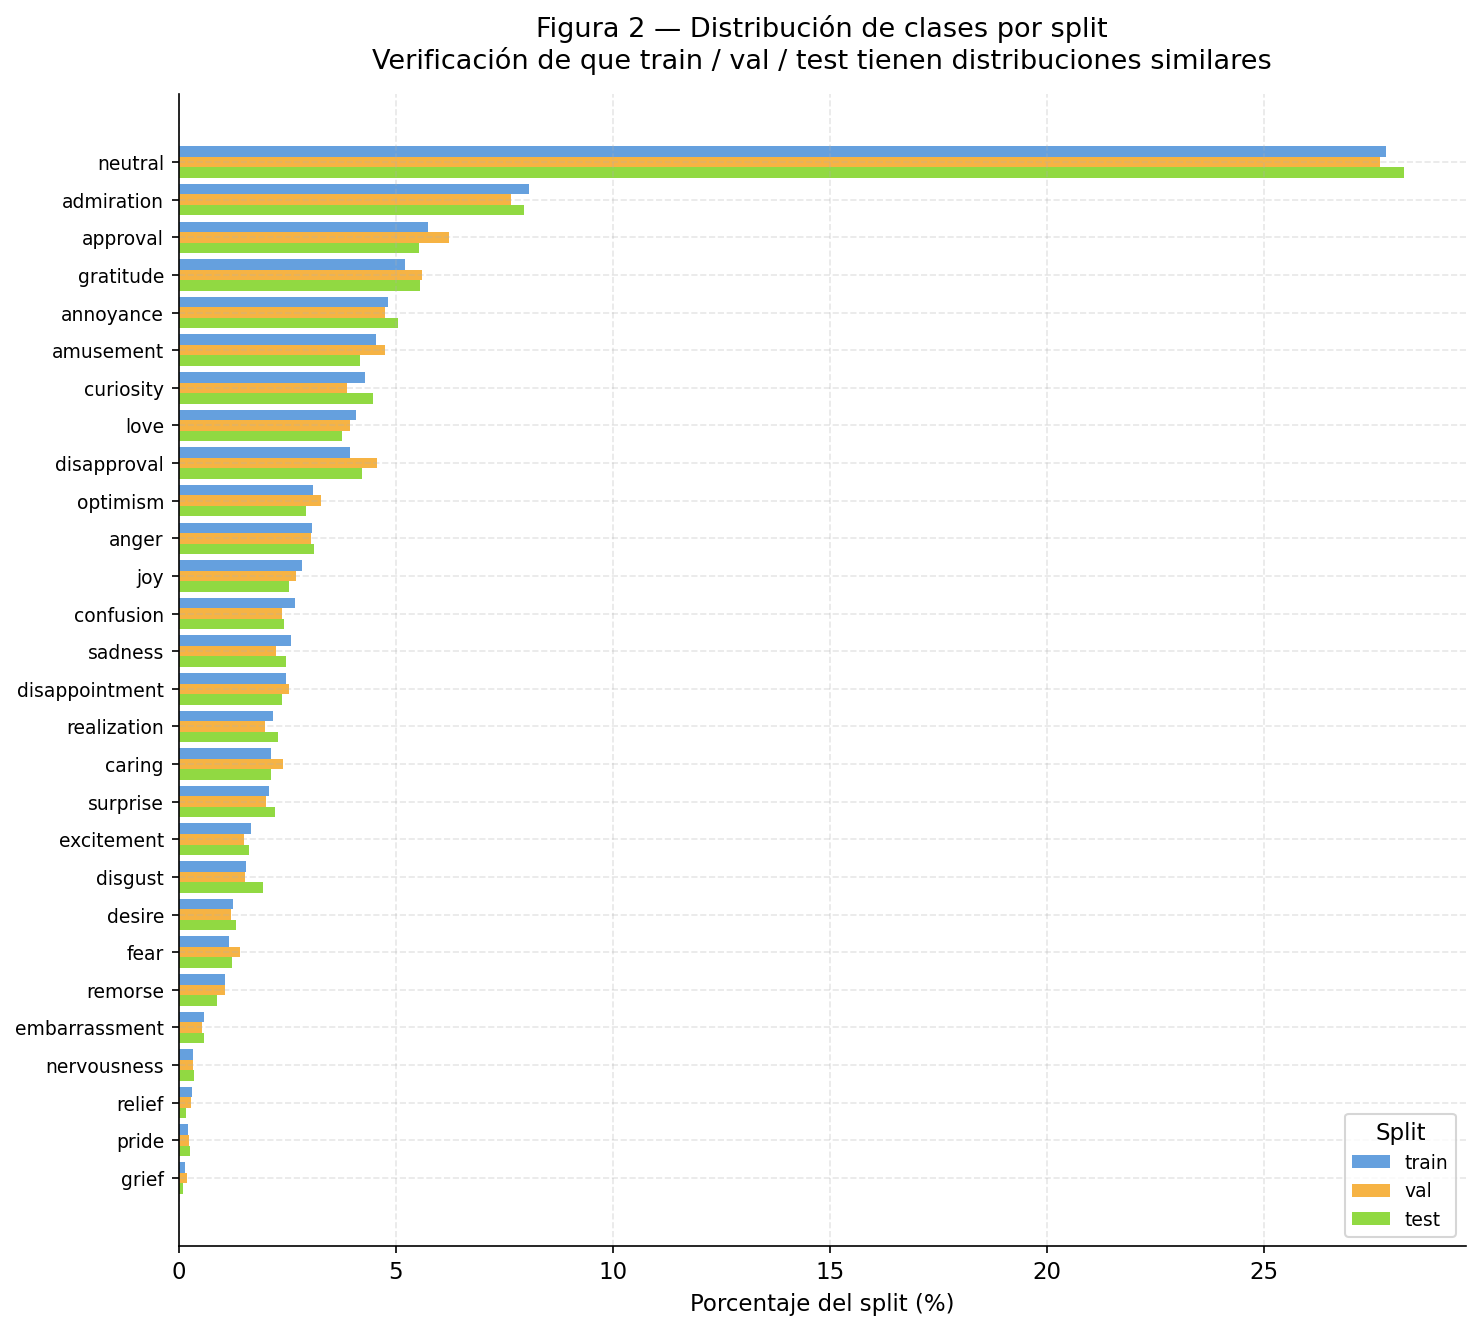

✓ Figura 2 guardada.


In [8]:
# ── Figura 2: Distribución por split (train / val / test) ─────────────────────
split_counts = (
    df_all.groupby(['split', 'label_name'])
    .size()
    .reset_index(name='count')
)
# Normalizar dentro de cada split
split_totals = split_counts.groupby('split')['count'].transform('sum')
split_counts['pct'] = split_counts['count'] / split_totals * 100

pivot = split_counts.pivot(index='label_name', columns='split', values='pct')
# Ordenar por frecuencia en train
order = class_counts['emotion'].tolist()
pivot = pivot.reindex(order)

fig, ax = plt.subplots(figsize=(10, 9))
x = np.arange(len(pivot))
width = 0.28
splits = ['train', 'val', 'test']
palette = ['#4a90d9', '#f5a623', '#7ed321']

for i, (split, color) in enumerate(zip(splits, palette)):
    if split in pivot.columns:
        ax.barh(x + i * width, pivot[split], width,
                label=split, color=color, alpha=0.85, edgecolor='none')

ax.set_yticks(x + width)
ax.set_yticklabels(pivot.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Porcentaje del split (%)')
fig_title(ax, 'Figura 2 — Distribución de clases por split\n'
             'Verificación de que train / val / test tienen distribuciones similares',
             pad=12)
ax.legend(title='Split', fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig02_distribution_by_split.png')
fig.savefig(FIG_DIR / 'fig02_distribution_by_split.pdf')
plt.show()
print('✓ Figura 2 guardada.')

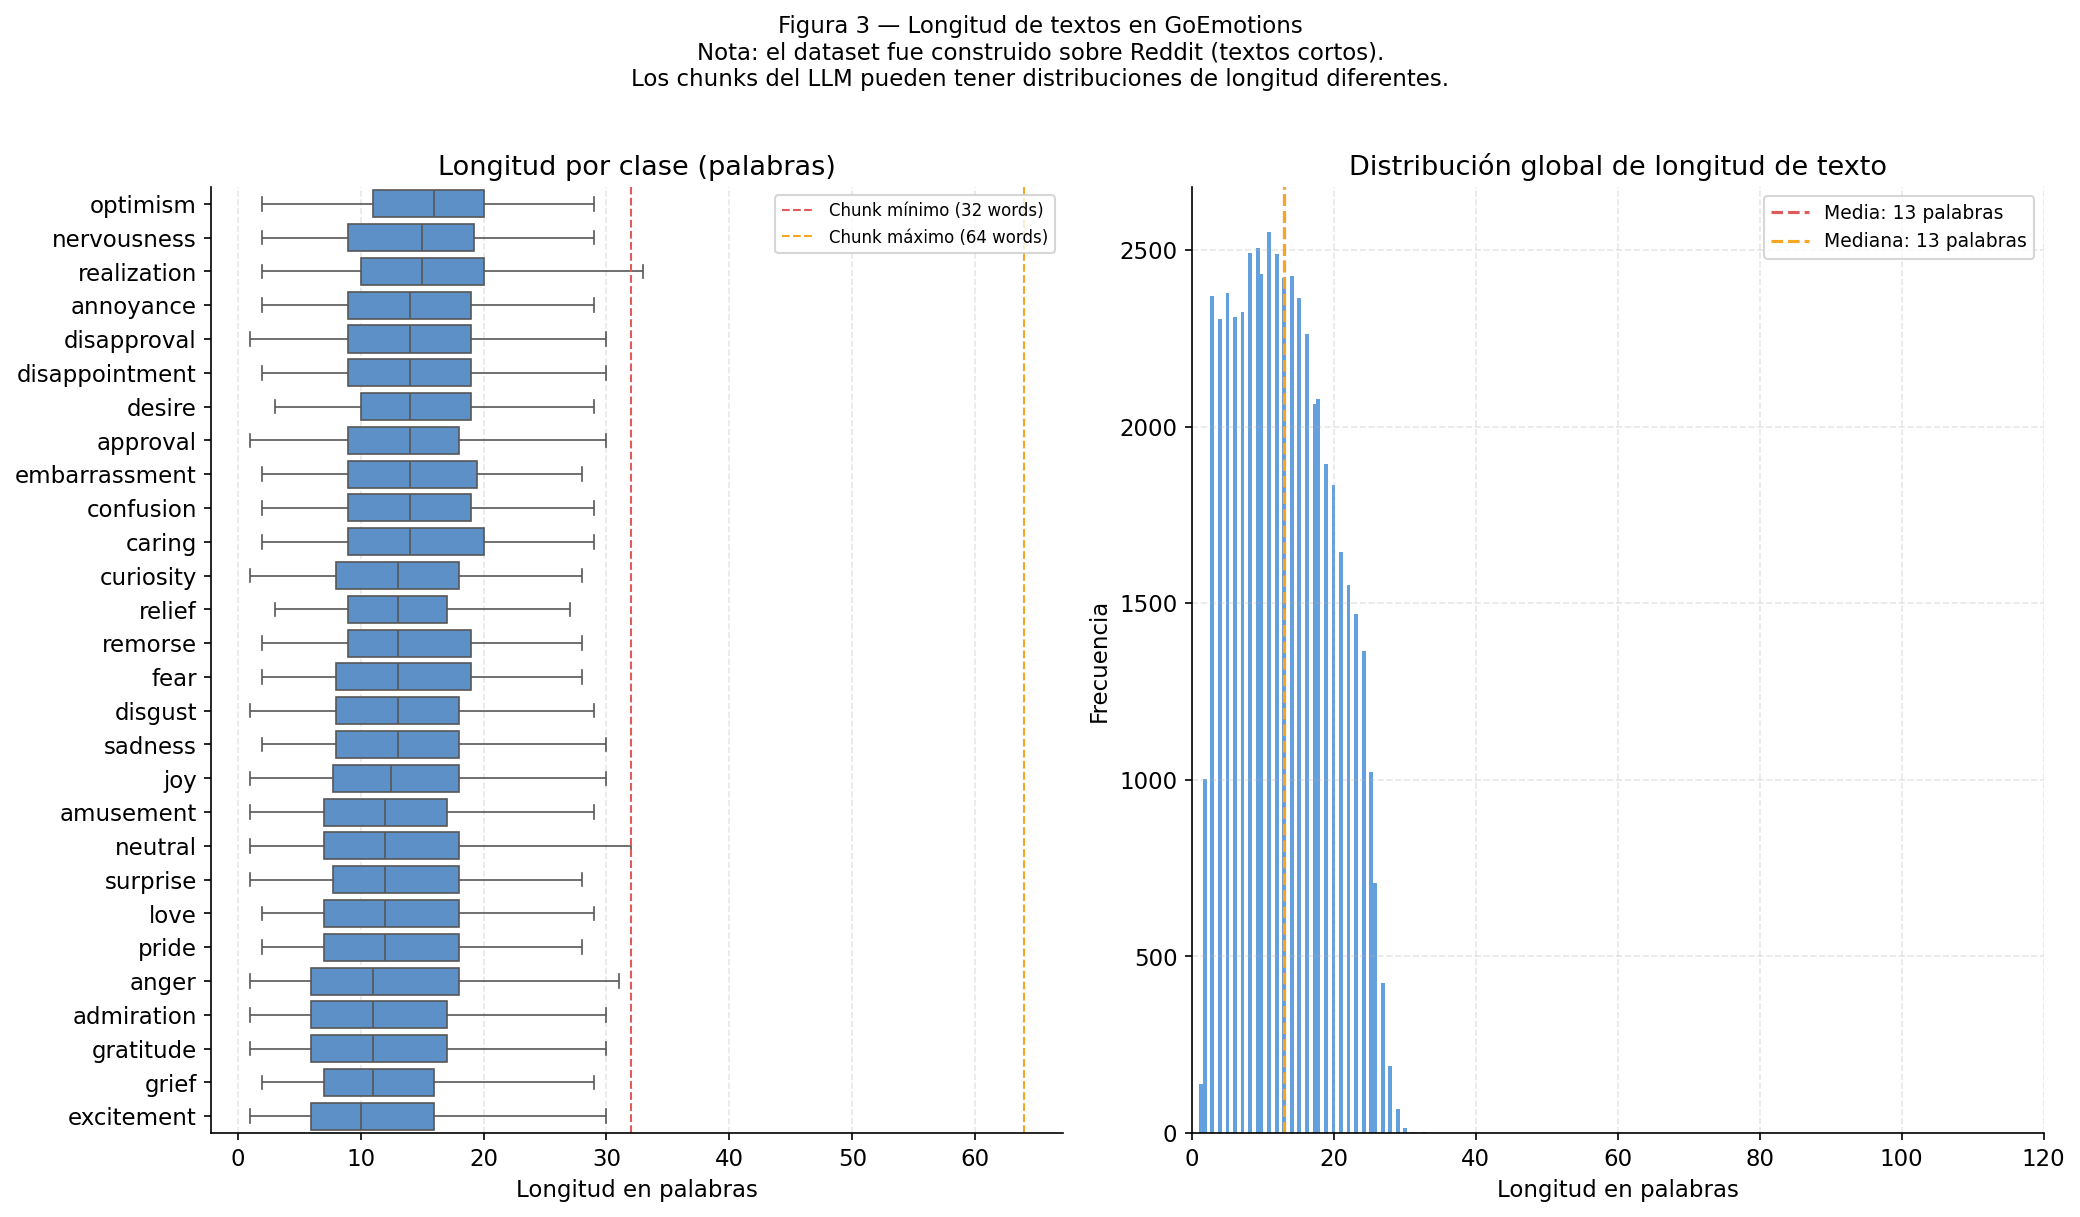

✓ Figura 3 guardada.

Longitud media de texto: 13.0 palabras
Longitud mediana:        13.0 palabras

→ Decisión de diseño: el chunk mínimo de 32 tokens cubre la mediana del dataset.


In [9]:
# ── Figura 3: Longitud de texto por clase ─────────────────────────────────────
# Relevante para el paper: determina qué tan representativos son los chunks
# del LLM vs el texto de Reddit en el dataset de entrenamiento.

df_train_meta = df_train.copy()
df_train_meta['n_chars']  = df_train_meta['text'].str.len()
df_train_meta['n_words']  = df_train_meta['text'].str.split().str.len()
df_train_meta['n_tokens_est'] = (df_train_meta['n_words'] * 1.3).round().astype(int)  # aprox

len_stats = (
    df_train_meta
    .groupby('label_name')[['n_words', 'n_tokens_est']]
    .agg(['mean', 'median', 'std'])
    .round(1)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Box plot de longitud en palabras por clase
order_by_median = (
    df_train_meta.groupby('label_name')['n_words']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
sns.boxplot(
    data=df_train_meta,
    y='label_name', x='n_words',
    order=order_by_median,
    ax=ax1,
    color='#4a90d9',
    fliersize=2, linewidth=0.8,
    showfliers=False,
)
ax1.axvline(32, color='#e05c5c', linestyle='--', linewidth=1,
            label='Chunk mínimo (32 words)')
ax1.axvline(64, color='#f5a623', linestyle='--', linewidth=1,
            label='Chunk máximo (64 words)')
ax1.set_xlabel('Longitud en palabras')
ax1.set_ylabel('')
ax1.set_title('Longitud por clase (palabras)')
ax1.legend(fontsize=8)

# Histograma global de longitud
ax2.hist(df_train_meta['n_words'], bins=60, color='#4a90d9',
         edgecolor='none', alpha=0.85)
ax2.axvline(df_train_meta['n_words'].mean(), color='#e05c5c',
            linestyle='--', label=f'Media: {df_train_meta["n_words"].mean():.0f} palabras')
ax2.axvline(df_train_meta['n_words'].median(), color='#f5a623',
            linestyle='--', label=f'Mediana: {df_train_meta["n_words"].median():.0f} palabras')
ax2.set_xlabel('Longitud en palabras')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución global de longitud de texto')
ax2.set_xlim(0, 120)
ax2.legend(fontsize=9)

fig_title(fig, 'Figura 3 — Longitud de textos en GoEmotions\n'
             'Nota: el dataset fue construido sobre Reddit (textos cortos).\n'
             'Los chunks del LLM pueden tener distribuciones de longitud diferentes.',
             fontsize=11, y=1.01)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig03_text_length.png', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig03_text_length.pdf', bbox_inches='tight')
plt.show()
print('✓ Figura 3 guardada.')
print(f'\nLongitud media de texto: {df_train_meta["n_words"].mean():.1f} palabras')
print(f'Longitud mediana:        {df_train_meta["n_words"].median():.1f} palabras')
print('\n→ Decisión de diseño: el chunk mínimo de 32 tokens cubre la mediana del dataset.')

## 3. Análisis de Co-ocurrencia (versión multi-label)

En la versión `raw` del dataset, un mismo texto puede tener múltiples etiquetas.  
Este análisis muestra qué emociones se confunden con frecuencia — guía clave para  
decidir qué clases colapsar en el esquema final.

In [10]:
# ── Matriz de co-ocurrencia ───────────────────────────────────────────────────
# Usando la versión raw (multi-label)
train_raw = ds_raw['train']


# Verificar que las columnas de emoción existen en el dataset raw
sample       = train_raw[0]
emotion_cols = [name for name in LABEL_NAMES if name in sample]
missing      = [name for name in LABEL_NAMES if name not in sample]
print(f'Columnas de emoción encontradas: {len(emotion_cols)}/{N_CLASSES}')
if missing:
    print(f'  Advertencia — columnas no encontradas: {missing}')
non_text = {k: v for k, v in sample.items() if k != 'text'}
print(f'Ejemplo de estructura raw: {non_text}\n')

# Construir matriz N_CLASSES x N_CLASSES
cooc = np.zeros((N_CLASSES, N_CLASSES), dtype=int)

for example in tqdm(train_raw, desc='Calculando co-ocurrencias'):
    # Reconstruir lista de índices de emociones activas (valor == 1)
    active = [
        i for i, name in enumerate(LABEL_NAMES)
        if name in example and example[name] == 1
    ]
    for i in active:
        for j in active:
            if i != j:
                cooc[i, j] += 1

cooc_df = pd.DataFrame(cooc, index=LABEL_NAMES, columns=LABEL_NAMES)

# Normalizar: P(j | i) = co-ocurrencias(i,j) / ocurrencias(i)
row_sums = cooc_df.sum(axis=1).to_numpy(copy=True).reshape(-1, 1)
row_sums[row_sums == 0] = 1
cooc_norm    = cooc_df.values / row_sums
cooc_norm_df = pd.DataFrame(cooc_norm, index=LABEL_NAMES, columns=LABEL_NAMES)

print('✓ Matriz de co-ocurrencia calculada.')
print(f'  Shape: {cooc_df.shape}')
print(f'  Total co-ocurrencias registradas: {cooc_df.values.sum():,}')

# Guardar
cooc_df.to_parquet(OUT_DIR / 'cooccurrence_matrix.parquet')
cooc_norm_df.to_parquet(OUT_DIR / 'cooccurrence_normalized.parquet')
print(f'  Guardado en {OUT_DIR}/')

Columnas de emoción encontradas: 28/28
Ejemplo de estructura raw: {'id': 'eew5j0j', 'author': 'Brdd9', 'subreddit': 'nrl', 'link_id': 't3_ajis4z', 'parent_id': 't1_eew18eq', 'created_utc': 1548381056.0, 'rater_id': 1, 'example_very_unclear': False, 'admiration': 0, 'amusement': 0, 'anger': 0, 'annoyance': 0, 'approval': 0, 'caring': 0, 'confusion': 0, 'curiosity': 0, 'desire': 0, 'disappointment': 0, 'disapproval': 0, 'disgust': 0, 'embarrassment': 0, 'excitement': 0, 'fear': 0, 'gratitude': 0, 'grief': 0, 'joy': 0, 'love': 0, 'nervousness': 0, 'optimism': 0, 'pride': 0, 'realization': 0, 'relief': 0, 'remorse': 0, 'sadness': 1, 'surprise': 0, 'neutral': 0}



Calculando co-ocurrencias: 100%|██████████| 211225/211225 [00:28<00:00, 7495.88it/s]


✓ Matriz de co-ocurrencia calculada.
  Shape: (28, 28)
  Total co-ocurrencias registradas: 97,794
  Guardado en data/


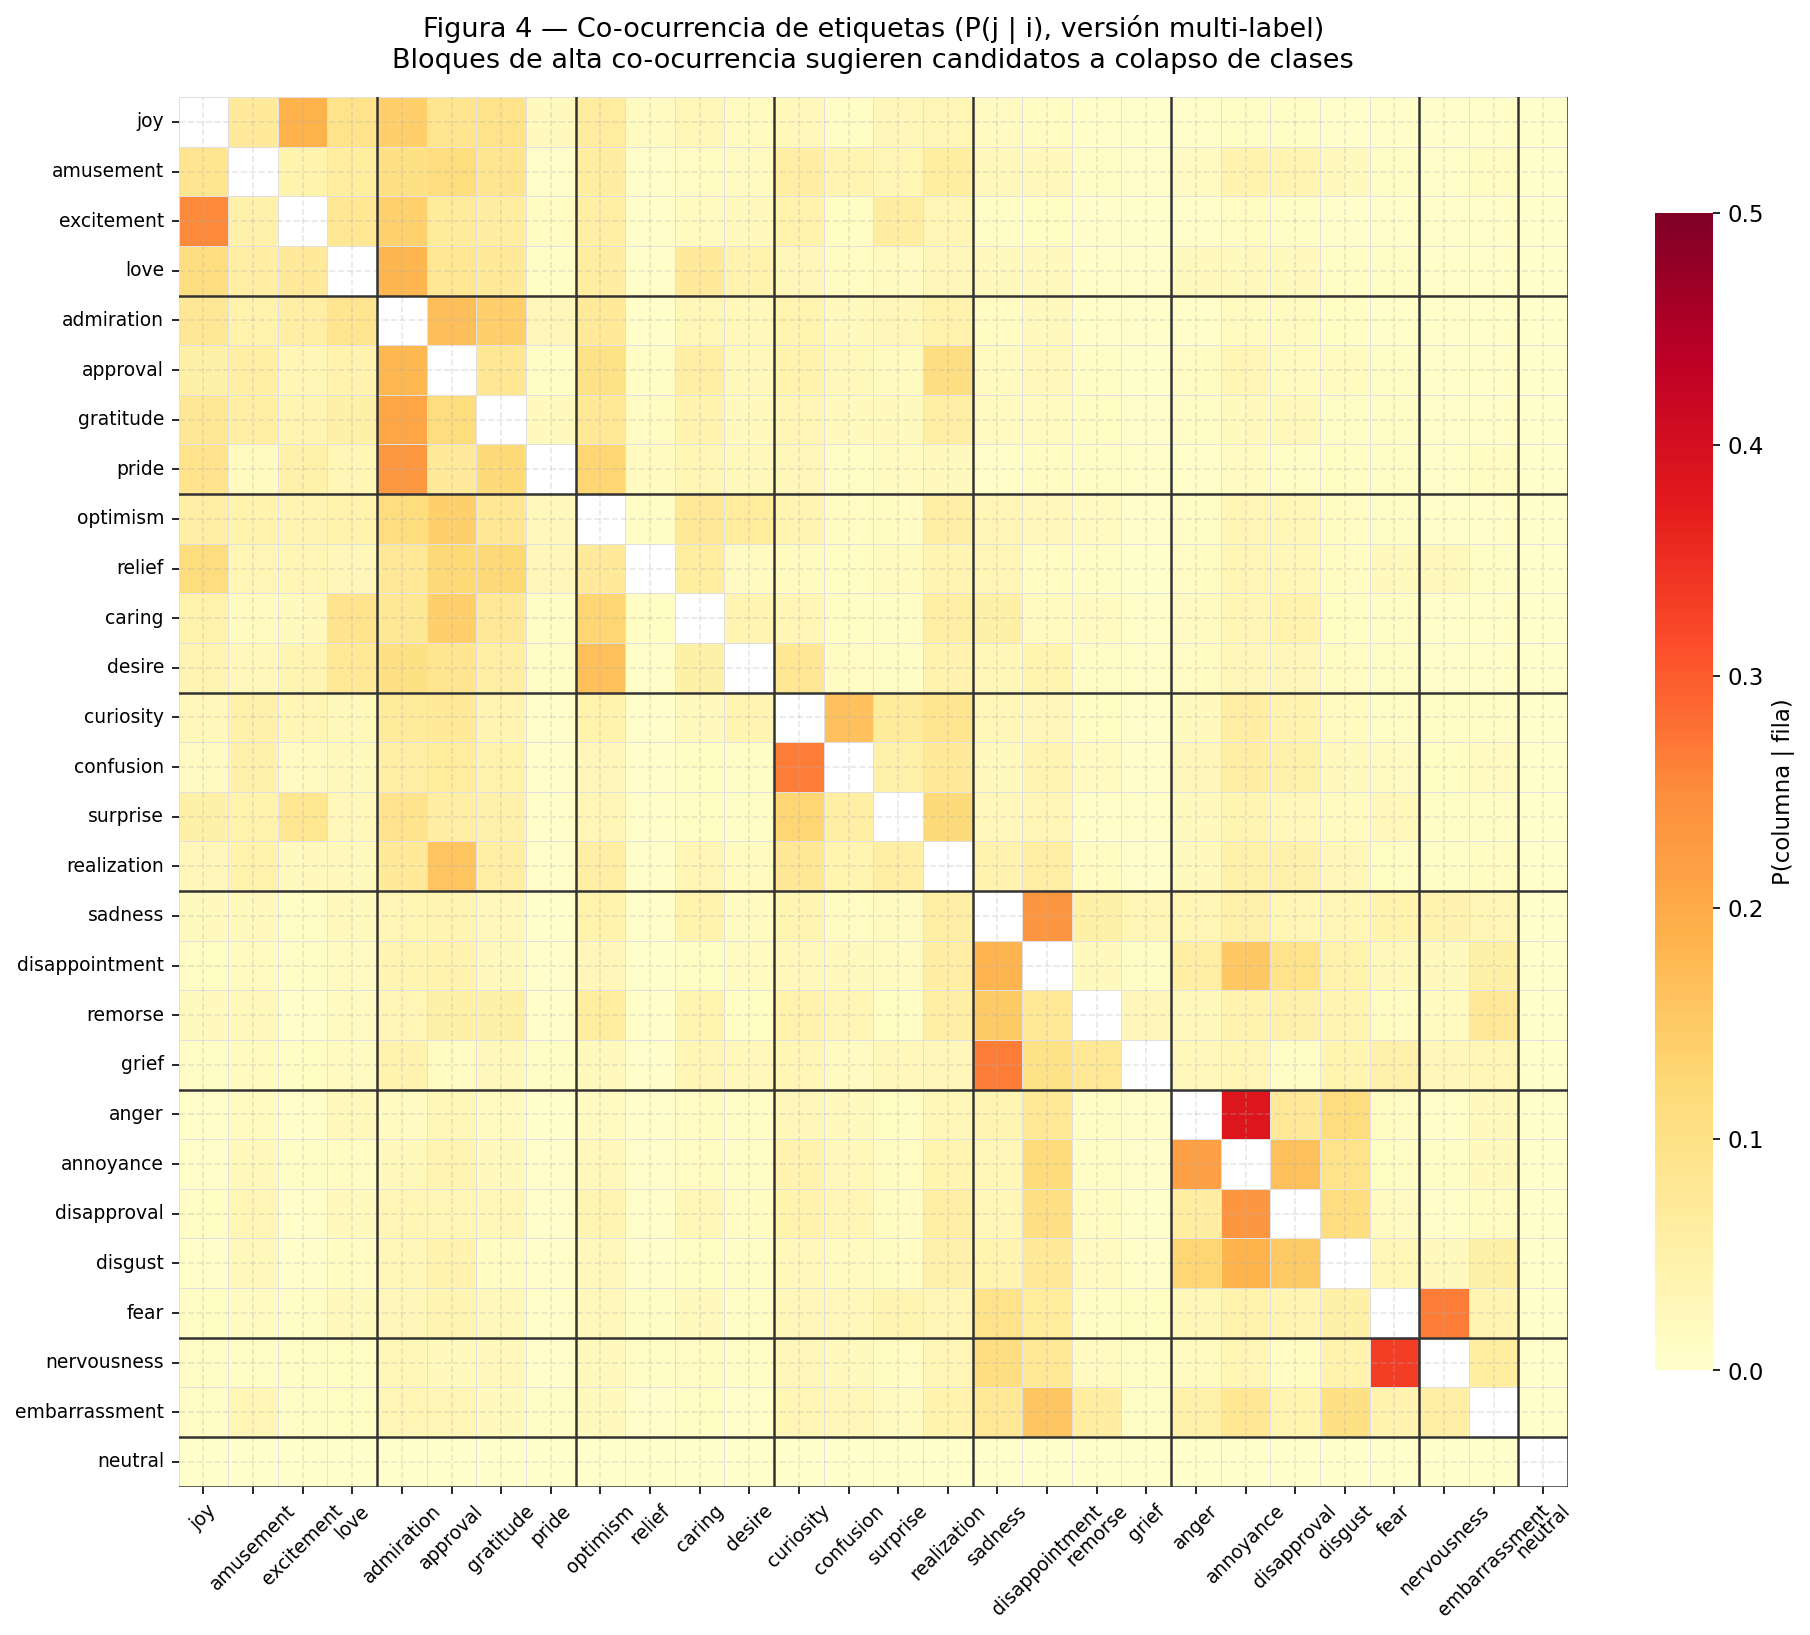

✓ Figura 4 guardada.

→ Los bloques cálidos revelan qué emociones se confunden naturalmente en el texto.
  Esta figura guía empíricamente el colapso de clases para el esquema final.


In [11]:
# ── Figura 4: Heatmap de co-ocurrencia normalizada ────────────────────────────
# Ordena las clases por grupo semántico para que los bloques sean visibles
SEMANTIC_ORDER = [
    # Positivas
    'joy', 'amusement', 'excitement', 'love',
    'admiration', 'approval', 'gratitude', 'pride',
    'optimism', 'relief', 'caring', 'desire',
    # Cognitivas / ambiguas
    'curiosity', 'confusion', 'surprise', 'realization',
    # Negativas
    'sadness', 'disappointment', 'remorse', 'grief',
    'anger', 'annoyance', 'disapproval', 'disgust',
    'fear', 'nervousness', 'embarrassment',
    # Neutral
    'neutral',
]
# Solo incluir clases que existen en el dataset
SEMANTIC_ORDER = [c for c in SEMANTIC_ORDER if c in LABEL_NAMES]
# Añadir las que no estén en el orden manual (failsafe)
SEMANTIC_ORDER += [c for c in LABEL_NAMES if c not in SEMANTIC_ORDER]

cooc_ordered = cooc_norm_df.loc[SEMANTIC_ORDER, SEMANTIC_ORDER]

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.eye(len(SEMANTIC_ORDER), dtype=bool)  # ocultar diagonal

sns.heatmap(
    cooc_ordered,
    mask=mask,
    cmap='YlOrRd',
    vmin=0, vmax=0.5,
    square=True,
    linewidths=0.3,
    linecolor='#e0e0e0',
    annot=False,
    cbar_kws={'label': 'P(columna | fila)', 'shrink': 0.8},
    ax=ax
)

# Separadores de grupos semánticos
group_sizes = [4, 8, 12, 16, 20, 25, 27, 28]
for gs in group_sizes:
    if gs <= len(SEMANTIC_ORDER):
        ax.axhline(gs, color='#333333', linewidth=1.2)
        ax.axvline(gs, color='#333333', linewidth=1.2)

fig_title(ax, 'Figura 4 — Co-ocurrencia de etiquetas (P(j | i), versión multi-label)\n'
             'Bloques de alta co-ocurrencia sugieren candidatos a colapso de clases',
             pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig04_cooccurrence_heatmap.png', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig04_cooccurrence_heatmap.pdf', bbox_inches='tight')
plt.show()
print('✓ Figura 4 guardada.')
print('\n→ Los bloques cálidos revelan qué emociones se confunden naturalmente en el texto.')
print('  Esta figura guía empíricamente el colapso de clases para el esquema final.')

In [12]:
# ── Top co-ocurrencias: candidatos concretos a colapso ────────────────────────
# Extraer los pares con mayor co-ocurrencia mutua
pairs = []
for i, label_i in enumerate(LABEL_NAMES):
    for j, label_j in enumerate(LABEL_NAMES):
        if i >= j:
            continue
        mutual = (cooc_norm_df.loc[label_i, label_j] +
                  cooc_norm_df.loc[label_j, label_i]) / 2
        pairs.append({'emotion_a': label_i, 'emotion_b': label_j,
                      'mutual_cooc': round(mutual, 4)})

pairs_df = pd.DataFrame(pairs).sort_values('mutual_cooc', ascending=False)

print('── Top 20 pares con mayor co-ocurrencia mutua ──')
print('   (candidatos a colapso de clases)\n')
print(pairs_df.head(20).to_string(index=False))

pairs_df.to_csv(OUT_DIR / 'cooccurrence_pairs_ranked.csv', index=False)
print(f'\n✓ Tabla guardada en {OUT_DIR / "cooccurrence_pairs_ranked.csv"}')

── Top 20 pares con mayor co-ocurrencia mutua ──
   (candidatos a colapso de clases)

     emotion_a      emotion_b  mutual_cooc
         anger      annoyance       0.3017
          fear    nervousness       0.2999
    excitement            joy       0.2205
     confusion      curiosity       0.2146
disappointment        sadness       0.2086
     annoyance    disapproval       0.2000
    admiration      gratitude       0.1759
    admiration       approval       0.1727
         grief        sadness       0.1503
     annoyance        disgust       0.1407
     annoyance disappointment       0.1352
    admiration           love       0.1346
      approval    realization       0.1339
    admiration          pride       0.1316
   disapproval        disgust       0.1299
         anger        disgust       0.1205
      approval       optimism       0.1191
        desire       optimism       0.1155
    admiration            joy       0.1102
disappointment  embarrassment       0.1036

✓ Tabla gu

## 4. Análisis de Ejemplos por Clase

Inspección cualitativa: muestra ejemplos reales de cada clase para validar  
que el colapso de etiquetas tiene sentido semántico, no solo estadístico.

In [ ]:
# ── Muestreo de ejemplos por clase ───────────────────────────────────────────
N_SAMPLES = 3  # ejemplos por clase a mostrar

print('═' * 70)
print(f'MUESTRA DE {N_SAMPLES} EJEMPLOS POR CLASE (train set)')
print('═' * 70)

for emotion in SEMANTIC_ORDER:
    subset = df_train[df_train['label_name'] == emotion]['text']
    samples = subset.sample(min(N_SAMPLES, len(subset)), random_state=SEED).tolist()
    count   = len(subset)

    print(f'\n── {emotion.upper()} ({count:,} ejemplos) ──')
    for i, text in enumerate(samples, 1):
        # Truncar textos muy largos para legibilidad
        display = text[:200] + '...' if len(text) > 200 else text
        print(f'  [{i}] {display}')

══════════════════════════════════════════════════════════════════════
MUESTRA DE 3 EJEMPLOS POR CLASE (train set)
══════════════════════════════════════════════════════════════════════

── JOY (1,452 ejemplos) ──
  [1] ive had 300ug tabs before, took 2 had full on ego death was naked with my friends jumping on moving cars 
  [2] This is the sweetest.
  [3] Happy new year!

── AMUSEMENT (2,328 ejemplos) ──
  [1] Yeah but it's fun lol. Hes banned a lot in NA also.
  [2] been there dont remember where exactly it is but so much fun
  [3] > LMAO, it's not free shit head, where the fuck is the source codes? This the real question.

── EXCITEMENT (853 ejemplos) ──
  [1] How to instantly look 20 years younger!
  [2] oh happy cake day
  [3] Chipotleee! [NAME] Damitt! Closes in 39 Seconds.. but we made it!! Loved this guy!!

── LOVE (2,086 ejemplos) ──
  [1] Yeah, I was like "man I love [NAME] so much but [NAME] is also amazing and good"
  [2] I actually liked them. I love the idea of Conqueror

## 5. Propuesta de Esquema de Clases

Con base en el análisis de distribución y co-ocurrencia, definimos un esquema  
intermedio de **11–14 clases** que:

1. Preserva distinción semántica real (no colapsa por conveniencia)
2. Garantiza suficientes ejemplos por clase para entrenamiento estable
3. Sobrevive a distintas personalidades del asistente (incluyendo perfiles excéntricos)
4. Le da al Avatar Controller y al TTS suficientes estados expresivos

> **Nota metodológica (paper):** El esquema a continuación es una propuesta inicial.
> El colapso definitivo se decidirá empíricamente tras entrenar el modelo y analizar
> la confusion matrix. Las clases que el modelo confunda sistemáticamente se colapsarán.

In [14]:
# ── Esquema de colapso propuesto ─────────────────────────────────────────────
# Modificar este diccionario para iterar sobre el esquema.
# Clave: nombre del grupo final. Valor: lista de clases GoEmotions que lo componen.

# Actualización: Ya se ha realizado pruebas y se concluyó que lo mejor es colapsar pride a la categoría admiratio y surprise a curiosity.

COLLAPSE_SCHEMA: dict[str, list[str]] = {
    # ── Positivas ──────────────────────────────────────────────────────────────
    'joy':         ['joy', 'amusement', 'excitement'],
    'love':        ['love', 'caring', 'gratitude'],
    'admiration':  ['admiration', 'approval', 'pride'],
    'optimism':    ['optimism', 'relief', 'desire'],

    # ── Cognitivas / epistémicas ───────────────────────────────────────────────
    'curiosity':   ['curiosity', 'realization', 'surprise', 'confusion'],

    # ── Negativas ─────────────────────────────────────────────────────────────
    'sadness':     ['sadness', 'grief', 'remorse', 'disappointment'],
    'anger':       ['anger', 'annoyance', 'disapproval'],
    'disgust':     ['disgust'],        # distinto de anger: rechazo visceral
    'fear':        ['fear', 'nervousness', 'embarrassment'],

    # ── Neutro ────────────────────────────────────────────────────────────────
    'neutral':     ['neutral'],
}

# Verificar que todas las clases de GoEmotions estén asignadas
assigned   = {c for classes in COLLAPSE_SCHEMA.values() for c in classes}
unassigned = set(LABEL_NAMES) - assigned
unknown    = assigned - set(LABEL_NAMES)

print('── Verificación del esquema de colapso ──')
print(f'  Clases GoEmotions:   {N_CLASSES}')
print(f'  Clases asignadas:    {len(assigned)}')
print(f'  Clases no asignadas: {len(unassigned)} → {unassigned or "ninguna"}')
print(f'  Clases inválidas:    {len(unknown)}    → {unknown or "ninguna"}')
print()
print(f'Grupos finales: {len(COLLAPSE_SCHEMA)}')
for group, members in COLLAPSE_SCHEMA.items():
    total = sum(
        len(df_train[df_train['label_name'] == m])
        for m in members
    )
    print(f'  {group:<14} ← {str(members):<60} ({total:,} ejemplos)')

── Verificación del esquema de colapso ──
  Clases GoEmotions:   28
  Clases asignadas:    28
  Clases no asignadas: 0 → ninguna
  Clases inválidas:    0    → ninguna

Grupos finales: 10
  joy            ← ['joy', 'amusement', 'excitement']                           (4,633 ejemplos)
  love           ← ['love', 'caring', 'gratitude']                              (5,835 ejemplos)
  admiration     ← ['admiration', 'approval', 'pride']                          (7,180 ejemplos)
  optimism       ← ['optimism', 'relief', 'desire']                             (2,375 ejemplos)
  curiosity      ← ['curiosity', 'realization', 'surprise', 'confusion']        (5,729 ejemplos)
  sadness        ← ['sadness', 'grief', 'remorse', 'disappointment']            (3,217 ejemplos)
  anger          ← ['anger', 'annoyance', 'disapproval']                        (6,059 ejemplos)
  disgust        ← ['disgust']                                                  (793 ejemplos)
  fear           ← ['fear', 'nervousnes

In [15]:
# ── Aplicar el esquema y generar el dataset colapsado ─────────────────────────
# Mapa inverso: go_emotions_label → grupo_final
label_to_group = {
    original: group
    for group, originals in COLLAPSE_SCHEMA.items()
    for original in originals
}

GROUP_NAMES = list(COLLAPSE_SCHEMA.keys())
GROUP2ID    = {name: i for i, name in enumerate(GROUP_NAMES)}
ID2GROUP    = {i: name for i, name in enumerate(GROUP_NAMES)}

def apply_collapse(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica el esquema de colapso a un DataFrame con columna 'label_name'.

    Un texto multi-label genera una fila por etiqueta; tras el colapso eso
    deja copias del mismo texto con grupos distintos — contradictorias para
    entrenamiento single-label y techo artificial en el F1 medido.
    Se conserva una sola fila por texto: la del grupo más raro, para
    proteger a las clases minoritarias.
    """
    out = df.copy()
    out['group_name'] = out['label_name'].map(label_to_group)
    out['group_id']   = out['group_name'].map(GROUP2ID)
    # Eliminar filas cuya label no tenga grupo asignado (failsafe)
    out = out.dropna(subset=['group_name'])
    # Deduplicar: una fila por texto, priorizando el grupo menos frecuente
    group_freq = out['group_name'].value_counts()
    out = (
        out.assign(_freq=out['group_name'].map(group_freq))
           .sort_values('_freq', kind='stable')
           .drop_duplicates(subset='text', keep='first')
           .drop(columns='_freq')
           .sample(frac=1, random_state=SEED)
           .reset_index(drop=True)
    )
    return out

df_train_c = apply_collapse(df_train)
df_val_c   = apply_collapse(df_val)
df_test_c  = apply_collapse(df_test)

print('Dataset colapsado:')
print(f'  Train: {len(df_train_c):,} filas')
print(f'  Val:   {len(df_val_c):,} filas')
print(f'  Test:  {len(df_test_c):,} filas')

# Guardar
df_train_c.to_parquet(OUT_DIR / 'train_collapsed.parquet', index=False)
df_val_c.to_parquet(OUT_DIR   / 'val_collapsed.parquet',   index=False)
df_test_c.to_parquet(OUT_DIR  / 'test_collapsed.parquet',  index=False)

# Guardar el esquema como JSON (parte del artefacto reproducible)
schema_meta = {
    'schema_version': '1.0',
    'n_groups':       len(GROUP_NAMES),
    'group_names':    GROUP_NAMES,
    'group2id':       GROUP2ID,
    'label_to_group': label_to_group,
    'collapse_schema': COLLAPSE_SCHEMA,
}
with open(OUT_DIR / 'collapse_schema.json', 'w') as f:
    json.dump(schema_meta, f, indent=2, ensure_ascii=False)

print(f'\n✓ Datos y esquema guardados en {OUT_DIR}/')

Dataset colapsado:
  Train: 51,103 filas
  Val:   6,380 filas
  Test:  6,329 filas

✓ Datos y esquema guardados en data/


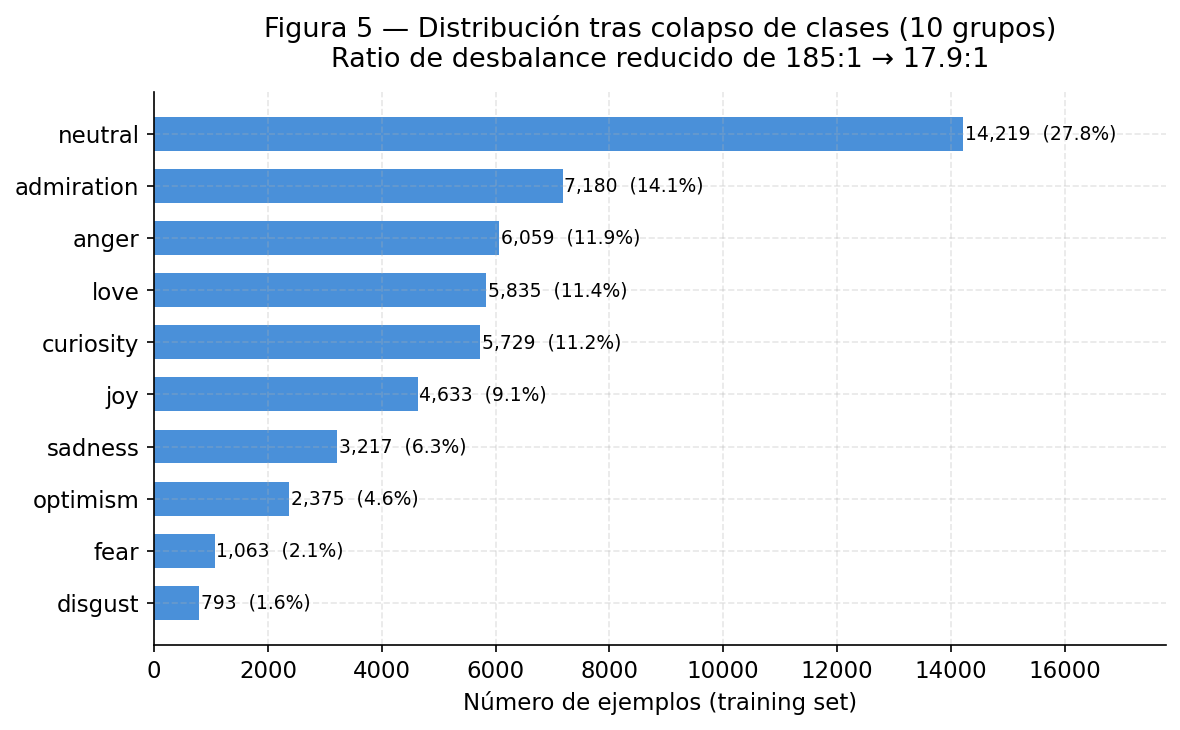

✓ Figura 5 guardada.

Ratio de desbalance original:  185:1
Ratio de desbalance colapsado: 17.9:1


In [16]:
# ── Figura 5: Distribución del esquema colapsado ──────────────────────────────
group_counts = (
    df_train_c['group_name']
    .value_counts()
    .rename_axis('group')
    .reset_index(name='count')
)
group_counts['pct'] = group_counts['count'] / group_counts['count'].sum() * 100

new_max   = group_counts['count'].max()
new_min   = group_counts['count'].min()
new_ratio = new_max / new_min

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    group_counts['group'],
    group_counts['count'],
    color='#4a90d9', edgecolor='none', height=0.65
)
for bar, row in zip(bars, group_counts.itertuples()):
    ax.text(
        bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
        f'{row.count:,}  ({row.pct:.1f}%)',
        va='center', ha='left', fontsize=9
    )

ax.invert_yaxis()
ax.set_xlabel('Número de ejemplos (training set)')
fig_title(ax, f'Figura 5 — Distribución tras colapso de clases ({len(GROUP_NAMES)} grupos)\n'
    f'Ratio de desbalance reducido de {imb_ratio:.0f}:1 → {new_ratio:.1f}:1',
    pad=12
)
ax.set_xlim(0, new_max * 1.25)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig05_collapsed_distribution.png')
fig.savefig(FIG_DIR / 'fig05_collapsed_distribution.pdf')
plt.show()
print(f'✓ Figura 5 guardada.')
print(f'\nRatio de desbalance original:  {imb_ratio:.0f}:1')
print(f'Ratio de desbalance colapsado: {new_ratio:.1f}:1')

## 6. Resumen y Artefactos Generados

Esta celda genera el resumen completo del notebook para incluir en el paper.

In [17]:
print('═' * 65)
print('RESUMEN — Notebook 01: Datos y Análisis Exploratorio')
print('═' * 65)

print(f"""
DATASET
  Fuente:             GoEmotions (Google Research, ACL 2020)
  Versión HuggingFace: google-research-datasets/go_emotions
  Clases originales:  {N_CLASSES}
  Total ejemplos:     {len(df_all):,}
  Train / Val / Test: {len(df_train):,} / {len(df_val):,} / {len(df_test):,}

DESBALANCE ORIGINAL
  Clase máxima:       {top_class} ({max_count:,} ejemplos)
  Clase mínima:       {bot_class} ({min_count:,} ejemplos)
  Ratio:              {imb_ratio:.0f}:1

ESQUEMA DE COLAPSO PROPUESTO
  Grupos finales:     {len(GROUP_NAMES)}
  Clases:             {', '.join(GROUP_NAMES)}
  Ratio post-colapso: {new_ratio:.1f}:1

LONGITUD DE TEXTO
  Media:              {df_train_meta['n_words'].mean():.1f} palabras
  Mediana:            {df_train_meta['n_words'].median():.1f} palabras
  Chunk window:       32–64 tokens (cubre la mediana del dataset)

SIGUIENTE PASO
  Notebook 02: Fine-tuning de DistilBERT con el esquema colapsado,
  class weights para compensar el desbalance residual, y evaluación
  con F1-macro, confusion matrix y curvas de calibración.
""")

print('ARTEFACTOS GENERADOS')
all_files = list(OUT_DIR.glob('*')) + list(FIG_DIR.glob('*'))
for f in sorted(all_files):
    size_kb = f.stat().st_size / 1024
    print(f'  {str(f):<55} {size_kb:>7.1f} KB')

print('\n═' * 65)

═════════════════════════════════════════════════════════════════
RESUMEN — Notebook 01: Datos y Análisis Exploratorio
═════════════════════════════════════════════════════════════════

DATASET
  Fuente:             GoEmotions (Google Research, ACL 2020)
  Versión HuggingFace: google-research-datasets/go_emotions
  Clases originales:  28
  Total ejemplos:     63,812
  Train / Val / Test: 51,103 / 6,380 / 6,329

DESBALANCE ORIGINAL
  Clase máxima:       neutral (14,219 ejemplos)
  Clase mínima:       grief (77 ejemplos)
  Ratio:              185:1

ESQUEMA DE COLAPSO PROPUESTO
  Grupos finales:     10
  Clases:             joy, love, admiration, optimism, curiosity, sadness, anger, disgust, fear, neutral
  Ratio post-colapso: 17.9:1

LONGITUD DE TEXTO
  Media:              13.0 palabras
  Mediana:            13.0 palabras
  Chunk window:       32–64 tokens (cubre la mediana del dataset)

SIGUIENTE PASO
  Notebook 02: Fine-tuning de DistilBERT con el esquema colapsado,
  class weights pa

# Español

## Descarga del dataset

In [18]:
# ── Descarga GoEmotions traducido al español ──────────────────────────────────
print('Descargando GoEmotions ES desde HuggingFace...')
ds_es = load_dataset('mrm8488/go_emotions-es-mt', trust_remote_code=False)
print(f'✓ Dataset ES descargado: {ds_es}')

Descargando GoEmotions ES desde HuggingFace...


Generating test split: 100%|██████████| 5427/5427 [00:00<00:00, 1267752.04 examples/s]

✓ Dataset ES descargado: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id', 'text_es'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id', 'text_es'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id', 'text_es'],
        num_rows: 5427
    })
})


## Verificar compatibilidad

In [19]:
# Verificar que las columnas del dataset ES coinciden con el EN
sample_es = ds_es['train'][0]
sample_en = ds_simplified['train'][0]

print('Columnas EN:', list(sample_en.keys()))
print('Columnas ES:', list(sample_es.keys()))
print()

# Verificar que ambos tienen los mismos campos de emoción
cols_en = set(sample_en.keys())
cols_es = set(sample_es.keys())
diff = cols_en.symmetric_difference(cols_es)
if diff:
    print(f'⚠ Diferencias en columnas: {diff}')
else:
    print('✓ Esquemas compatibles — mismas columnas en ambos datasets')

Columnas EN: ['text', 'labels', 'id']
Columnas ES: ['text', 'labels', 'id', 'text_es']

⚠ Diferencias en columnas: {'text_es'}


## Preparar y combinar datasets

In [21]:
from datasets import concatenate_datasets, ClassLabel, Sequence

def prepare_es_split(split, label_feature):
    """Reemplaza text con text_es, elimina columnas redundantes
    y castea labels al mismo tipo ClassLabel que el dataset EN."""
    # Reemplazar text con la traducción española
    split = split.map(lambda x: {'text': x['text_es']})
    # Eliminar columna text_es ya innecesaria
    split = split.remove_columns(['text_es'])
    # Castear labels a ClassLabel para que coincida con el dataset EN
    split = split.cast_column('labels', Sequence(label_feature))
    return split

# Extraer el tipo ClassLabel del dataset EN para usarlo como referencia
label_feature = ds_simplified['train'].features['labels'].feature

print('Preparando dataset ES...')
ds_es_train = prepare_es_split(ds_es['train'],      label_feature)
ds_es_val   = prepare_es_split(ds_es['validation'], label_feature)
ds_es_test  = prepare_es_split(ds_es['test'],       label_feature)

# Etiquetar idioma — la augmentación de longitud necesita no mezclar idiomas
ds_es_train = ds_es_train.map(lambda x: {'lang': 'es'})
ds_es_val   = ds_es_val.map(lambda x: {'lang': 'es'})
ds_es_test  = ds_es_test.map(lambda x: {'lang': 'es'})
ds_en_train = ds_simplified['train'].map(lambda x: {'lang': 'en'})
ds_en_val   = ds_simplified['validation'].map(lambda x: {'lang': 'en'})
ds_en_test  = ds_simplified['test'].map(lambda x: {'lang': 'en'})

# Verificar que los features ahora coinciden
print(f'Features EN: {ds_simplified["train"].features}')
print(f'Features ES: {ds_es_train.features}')

# Combinar EN + ES mezclados aleatoriamente
ds_combined_train = concatenate_datasets([ds_en_train, ds_es_train]).shuffle(seed=SEED)
ds_combined_val   = concatenate_datasets([ds_en_val,   ds_es_val]).shuffle(seed=SEED)
ds_combined_test  = concatenate_datasets([ds_en_test,  ds_es_test]).shuffle(seed=SEED)

print(f'\n✓ Combinado y mezclado:')
print(f'  Train: {len(ds_combined_train):,}  ({len(ds_simplified["train"]):,} EN + {len(ds_es_train):,} ES)')
print(f'  Val:   {len(ds_combined_val):,}')
print(f'  Test:  {len(ds_combined_test):,}')

Preparando dataset ES...


Casting the dataset: 100%|██████████| 5427/5427 [00:00<00:00, 1672851.31 examples/s]

Features EN: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}
Features ES: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

✓ Combinado y mezclado:
  Train: 86,820  (43,410 EN + 43,410 ES)
  Val:   10,852
  Test:  10,854


## Convertir a DataFrames y guardar

In [23]:
print('Convirtiendo a DataFrames...')

def split_to_df_lang(dataset_split, label_names) -> pd.DataFrame:
    """Como split_to_df, pero conserva la columna 'lang' (en/es)."""
    rows = []
    for example in dataset_split:
        for label_id in example['labels']:
            rows.append({
                'text':       example['text'],
                'lang':       example['lang'],
                'label_id':   label_id,
                'label_name': label_names[label_id],
            })
    return pd.DataFrame(rows)

df_train = split_to_df_lang(ds_combined_train, LABEL_NAMES)
df_val   = split_to_df_lang(ds_combined_val,   LABEL_NAMES)
df_test  = split_to_df_lang(ds_combined_test,  LABEL_NAMES)

# Aplicar el mismo esquema de colapso (incluye deduplicación por texto)
df_train_c = apply_collapse(df_train)
df_val_c   = apply_collapse(df_val)
df_test_c  = apply_collapse(df_test)

print(f'  Train colapsado: {len(df_train_c):,}')
print(f'  Val colapsado:   {len(df_val_c):,}')
print(f'  Test colapsado:  {len(df_test_c):,}')

# ── Augmentación de longitud ─────────────────────────────────────────────────
# GoEmotions tiene mediana ~12 palabras; en producción el detector clasifica
# turnos de LLM de 64-200 tokens. Sin ejemplos largos, esos textos caen fuera
# de la distribución de entrenamiento y el modelo colapsa a neutral con
# confianza baja. Se generan ejemplos largos concatenando textos del mismo
# grupo e idioma. El muestreo uniforme sobre (grupo, idioma) además refuerza
# las clases raras (disgust, fear).

def augment_long_examples(df: pd.DataFrame, frac: float = 0.30, seed: int = SEED) -> pd.DataFrame:
    rng  = np.random.default_rng(seed)
    pool = {
        key: sub['text'].tolist()
        for key, sub in df.groupby(['group_name', 'lang'])
        if len(sub) >= 10
    }
    keys  = list(pool.keys())
    n_aug = int(len(df) * frac)
    rows  = []
    for _ in range(n_aug):
        group, lang = keys[int(rng.integers(len(keys)))]
        texts  = pool[(group, lang)]
        target = int(rng.integers(50, 160))          # palabras objetivo
        parts, total = [], 0
        for i in rng.permutation(len(texts)):
            t = texts[int(i)].strip()
            if not t:
                continue
            parts.append(t if t[-1] in '.!?…"' else t + '.')
            total += len(t.split())
            if total >= target:
                break
        rows.append({
            'text':       ' '.join(parts),
            'lang':       lang,
            'label_id':   -1,                        # sintético, sin label original
            'label_name': group,
            'group_name': group,
            'group_id':   GROUP2ID[group],
        })
    return pd.DataFrame(rows)

def pct_long(df: pd.DataFrame, thr_tokens: int = 64) -> float:
    est = df['text'].str.split().str.len() * 1.3     # aprox tokens
    return float((est >= thr_tokens).mean() * 100)

print(f'\n  Train con ≥64 tokens (est.) antes: {pct_long(df_train_c):.1f}%')

aug_train  = augment_long_examples(df_train_c, frac=0.30, seed=SEED)
aug_val    = augment_long_examples(df_val_c,   frac=0.30, seed=SEED + 1)
df_train_c = pd.concat([df_train_c, aug_train]).sample(frac=1, random_state=SEED).reset_index(drop=True)
df_val_c   = pd.concat([df_val_c,   aug_val]).sample(frac=1, random_state=SEED).reset_index(drop=True)
# El test queda sin augmentar: mide rendimiento en datos reales

print(f'  Ejemplos largos generados: {len(aug_train):,} train + {len(aug_val):,} val')
print(f'  Train con ≥64 tokens (est.) después: {pct_long(df_train_c):.1f}%')
print(f'  Train final: {len(df_train_c):,} | Val final: {len(df_val_c):,}')

# Sobreescribir los parquets — el Notebook 02 los leerá automáticamente
df_train_c.to_parquet(OUT_DIR / 'train_collapsed.parquet', index=False)
df_val_c.to_parquet(OUT_DIR   / 'val_collapsed.parquet',   index=False)
df_test_c.to_parquet(OUT_DIR  / 'test_collapsed.parquet',  index=False)

print(f'\n✓ Parquets actualizados: EN+ES combinado, deduplicado y con augmentación de longitud')
print(f'  Los notebooks 02 y 03 los leerán automáticamente en la próxima ejecución.')


Convirtiendo a DataFrames...
  Train colapsado: 102,206
  Val colapsado:   12,760
  Test colapsado:  12,658
✓ Parquets actualizados con dataset combinado EN+ES
  Los notebooks 02 y 03 los leerán automáticamente en la próxima ejecución.
